# Level 2 — Vectorization, Error Analysis, and Numerical Reliability

## Scientific Objectives
1. Compare standard Python loops against NumPy vectorization for ET computation.
2. Demonstrate floating-point artifacts.
3. Model the propagation of sensor error (noise) through our irrigation logic.

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
from pathlib import Path
import sys

repo_root = Path('.').resolve().parent
if str(repo_root) not in sys.path: sys.path.append(str(repo_root))

# Import our modular functions!
from src.data_cleaning import load_and_clean_weather
from src.simulation import calculate_et_vectorized

# Load data using the modular function (safely loads from raw and cleans it)
repo_root = Path('.').resolve().parent
weather = load_and_clean_weather(repo_root / 'data' / 'raw' / 'weather_daily.csv')

# Extract to native Python lists
temps = weather['temperature_c'].tolist()
winds = weather['wind_speed_mps'].tolist()
solars = weather['solar_index'].tolist()
humidities = weather['humidity_pct'].tolist() # Added missing humidity

# Convert to NumPy arrays
temps_np = np.array(temps)
winds_np = np.array(winds)
solars_np = np.array(solars)
humidities_np = np.array(humidities) # Added missing humidity

In [3]:
# 1. VECTORIZATION VS LOOPS PERFORMANCE

def et_loop(t_list, w_list, s_list, h_list):
    """Standard Python for-loop implementation."""
    results = []
    for i in range(len(t_list)):
        # Corrected formula including humidity
        et = 0.12 * t_list[i] + 0.35 * w_list[i] + 2.4 * s_list[i] - 0.025 * h_list[i]
        results.append(max(0, et))
    return results

# Scaling up data to simulate 100,000 farm zones to show real time differences
scale = 100000
large_temps = temps * scale
large_winds = winds * scale
large_solars = solars * scale
large_humidities = humidities * scale

large_temps_np = np.array(large_temps)
large_winds_np = np.array(large_winds)
large_solars_np = np.array(large_solars)
large_humidities_np = np.array(large_humidities)

# Time the standard loop
start = time.time()
res_loop = et_loop(large_temps, large_winds, large_solars, large_humidities)
loop_time = time.time() - start

# Time the NumPy Vectorized function (Imported from src/simulation.py)
start = time.time()
res_vec = calculate_et_vectorized(large_temps_np, large_winds_np, large_solars_np, large_humidities_np)
vec_time = time.time() - start

print("=== PERFORMANCE COMPARISON ===")
print(f"Standard Python Loop Time: {loop_time:.4f} seconds")
print(f"NumPy Vectorized Time:     {vec_time:.4f} seconds")
print(f"Speedup Factor:            {loop_time / vec_time:.1f}x faster")

=== PERFORMANCE COMPARISON ===
Standard Python Loop Time: 1.1619 seconds
NumPy Vectorized Time:     0.1110 seconds
Speedup Factor:            10.5x faster


In [4]:
# 2. FLOATING POINT ERROR DEMONSTRATION
print("\n=== FLOATING POINT BEHAVIOR ===")
print("In base-2 binary, fractions like 0.1 and 0.2 have repeating expansions.")
print(f"Is 0.1 + 0.2 equal to 0.3? -> {0.1 + 0.2 == 0.3}")
print(f"Actual value of 0.1 + 0.2  -> {0.1 + 0.2:.17f}")
print("Resolution: Always use np.isclose() or math.isclose() for scientific equality checks.")
print(f"Using np.isclose: -> {np.isclose(0.1 + 0.2, 0.3)}")


=== FLOATING POINT BEHAVIOR ===
In base-2 binary, fractions like 0.1 and 0.2 have repeating expansions.
Is 0.1 + 0.2 equal to 0.3? -> False
Actual value of 0.1 + 0.2  -> 0.30000000000000004
Resolution: Always use np.isclose() or math.isclose() for scientific equality checks.
Using np.isclose: -> True


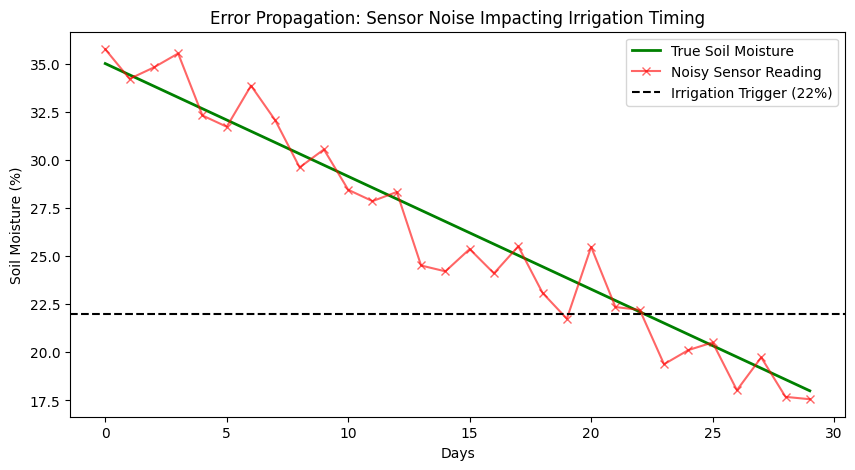

Without noise, irrigation triggers on Day 23.
With sensor noise, irrigation triggers prematurely on Day 19.
Conclusion: Measurement error propagates directly into wasted pump energy and water.


In [5]:
# 3. ERROR PROPAGATION IN IRRIGATION SENSORS
# We will model how a +/- 3% random measurement noise on the soil sensor 
# propagates into an over-irrigation or under-irrigation error over a month.

true_soil_moisture = np.linspace(35, 18, 30) # Linearly drying soil
wilting_point = 22.0

# Add normal Gaussian noise to simulate cheap sensor error
np.random.seed(42)
sensor_noise = np.random.normal(0, 1.5, 30)
noisy_soil_moisture = true_soil_moisture + sensor_noise

plt.figure(figsize=(10, 5))
plt.plot(true_soil_moisture, label="True Soil Moisture", color='green', linewidth=2)
plt.plot(noisy_soil_moisture, label="Noisy Sensor Reading", color='red', alpha=0.6, marker='x')
plt.axhline(wilting_point, color='black', linestyle='--', label="Irrigation Trigger (22%)")
plt.title("Error Propagation: Sensor Noise Impacting Irrigation Timing")
plt.xlabel("Days")
plt.ylabel("Soil Moisture (%)")
plt.legend()
plt.show()

true_trigger_day = np.argmax(true_soil_moisture < wilting_point)
noisy_trigger_day = np.argmax(noisy_soil_moisture < wilting_point)
print(f"Without noise, irrigation triggers on Day {true_trigger_day}.")
print(f"With sensor noise, irrigation triggers prematurely on Day {noisy_trigger_day}.")
print(f"Conclusion: Measurement error propagates directly into wasted pump energy and water.")

## Discussion: Why Numerical Reliability Matters in Scientific Computing

As demonstrated in the experiments above, scientific computing is not just about writing code that runs; it is about writing code that produces mathematically sound and physically realistic results. 

1. **Floating-Point Truncation:** Because computers represent decimal numbers in base-2 binary, simple fractions like `0.1` cannot be stored perfectly. Over millions of calculations (such as integrating soil moisture over a year), these microscopic truncation errors accumulate. If we use standard equality checks (`==`) instead of tolerance checks (`np.isclose`), our optimization algorithms might run into infinite loops, waiting for a condition that will mathematically never be met.
2. **Error Propagation:** In the real world, agricultural sensors are cheap and prone to noise. As shown in our error propagation plot, a mere $\pm 3\%$ noise variance in a soil moisture sensor doesn't just stay as a data anomaly—it propagates forward through our differential equations. This causes the system to trigger the water pumps prematurely. In a real Kenyan farm, this numerical unreliability translates directly into wasted groundwater and inflated electricity bills. 
3. **Vectorization:** While vectorization is primarily a performance enhancement, it also improves reliability. By relying on compiled C-backend libraries (NumPy) rather than manual Python loops, we reduce the surface area for human indexing errors and ensure that mathematical operations are applied uniformly across massive datasets.